<a href="https://colab.research.google.com/github/Tanuja781/Forest-cover-Type-Classicifier/blob/main/Forest_Cover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
df = pd.read_csv("/content/covtype.csv")
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2            234             238   

Cover_Type
2.0    163006
1.0     75545
3.0     11386
5.0      6005
6.0      5444
7.0      3971
4.0      2394
Name: count, dtype: int64
Missing values in Cover_Type:
1
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                       

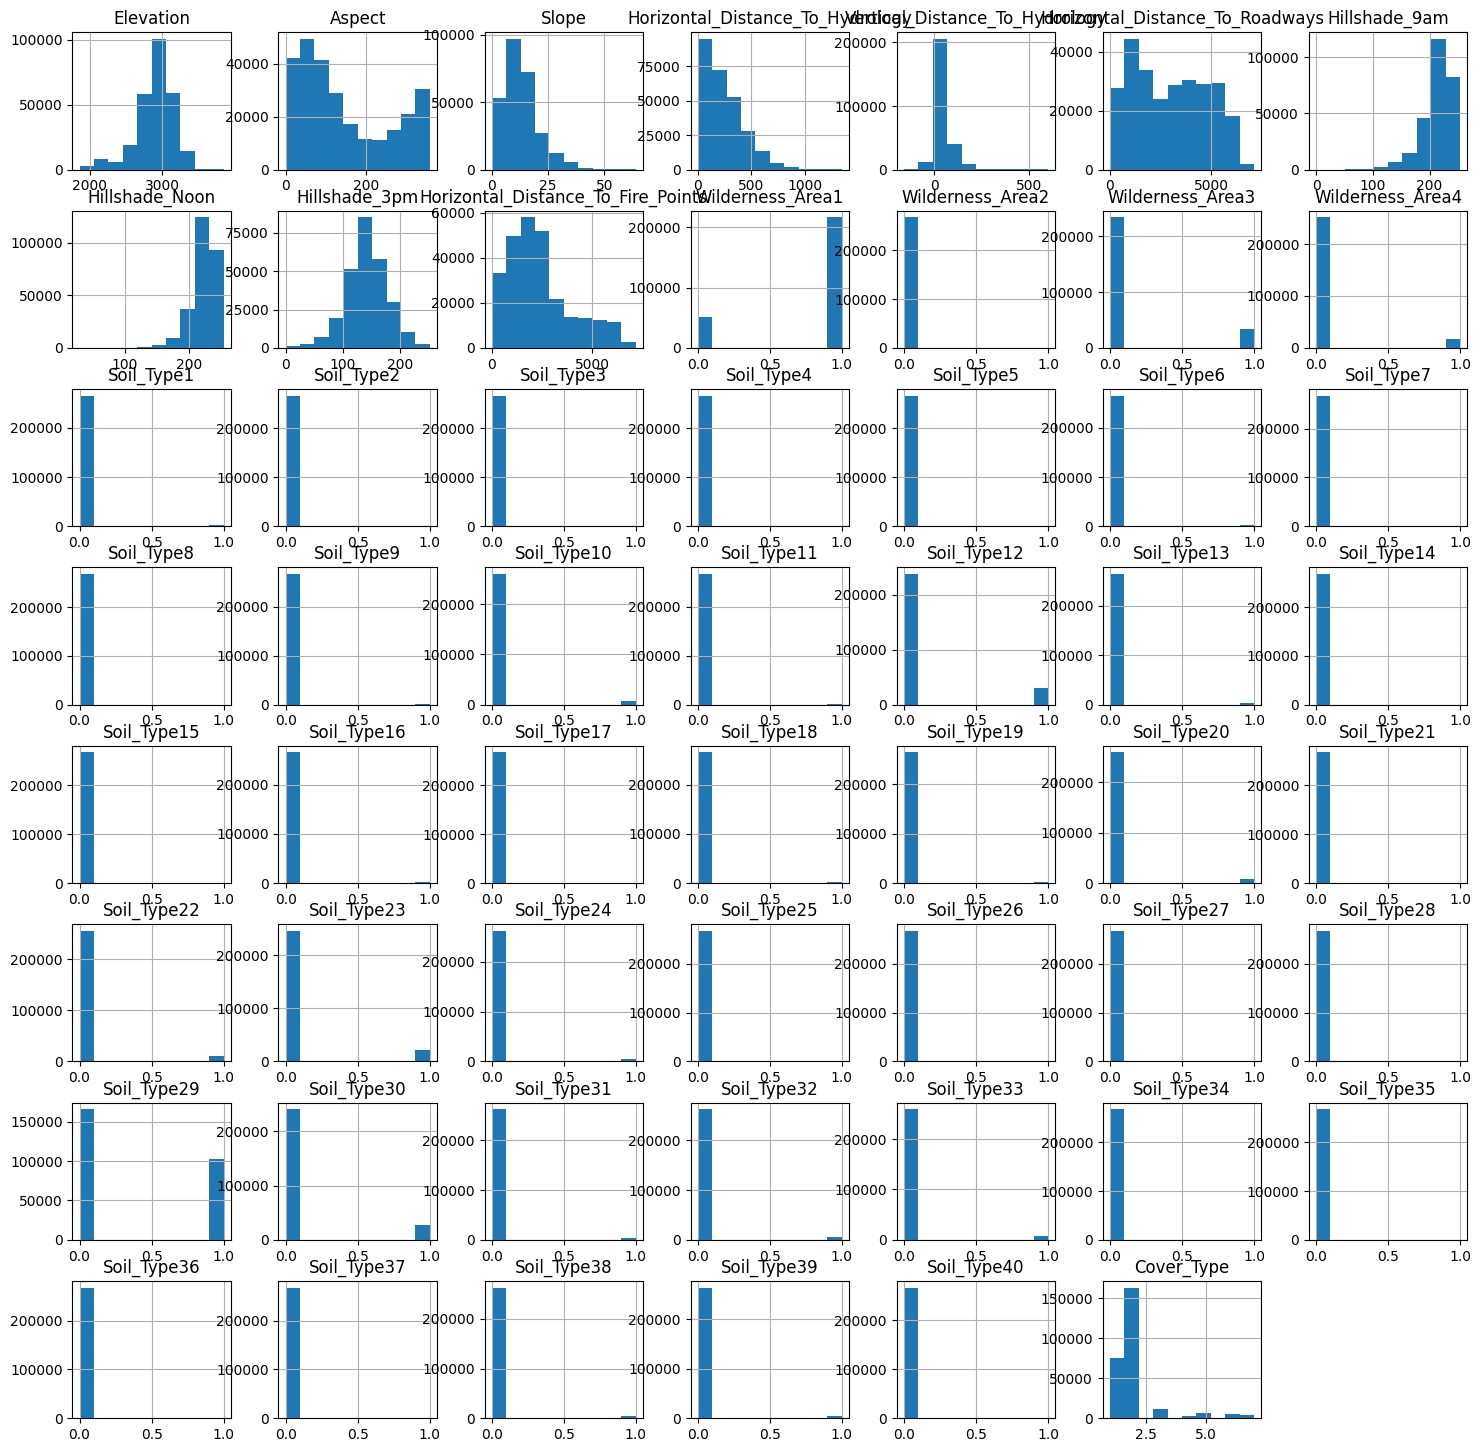

                                    Elevation    Aspect     Slope  \
Elevation                            1.000000 -0.029894 -0.377681   
Aspect                              -0.029894  1.000000  0.089814   
Slope                               -0.377681  0.089814  1.000000   
Horizontal_Distance_To_Hydrology     0.234109  0.007877 -0.052013   
Vertical_Distance_To_Hydrology      -0.044869  0.105725  0.320495   
Horizontal_Distance_To_Roadways      0.630245  0.061113 -0.299003   
Hillshade_9am                        0.187632 -0.567828 -0.340093   
Hillshade_Noon                       0.305702  0.299578 -0.636685   
Hillshade_3pm                        0.078384  0.623974 -0.233262   
Horizontal_Distance_To_Fire_Points   0.157450 -0.073558 -0.220391   
Wilderness_Area1                     0.485384 -0.134388 -0.423435   
Wilderness_Area2                     0.071849  0.010641  0.003318   
Wilderness_Area3                    -0.086668  0.098050  0.230130   
Wilderness_Area4                  

In [4]:
print(df["Cover_Type"].value_counts())

print("Missing values in Cover_Type:")
print(df["Cover_Type"].isnull().sum())
print(df.isnull().sum())

print("Total Missing Values:")
print(df.isnull().sum().sum())
df.hist(figsize=(18,18))
plt.show()
print(df.corr())


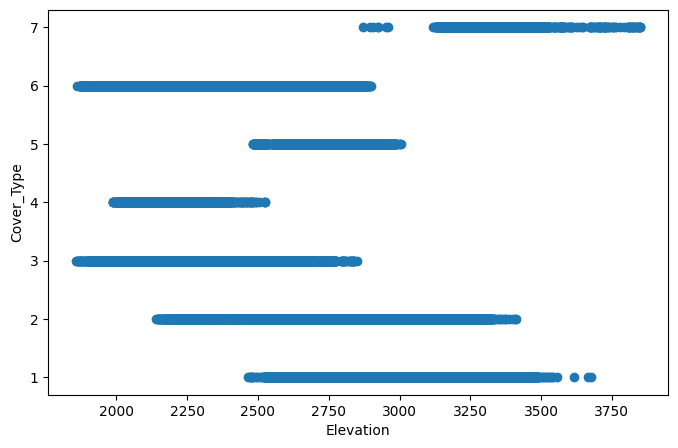

In [5]:
plt.figure(figsize=(8,5))
plt.scatter(df["Elevation"], df["Cover_Type"])
plt.xlabel("Elevation")
plt.ylabel("Cover_Type")
plt.show()

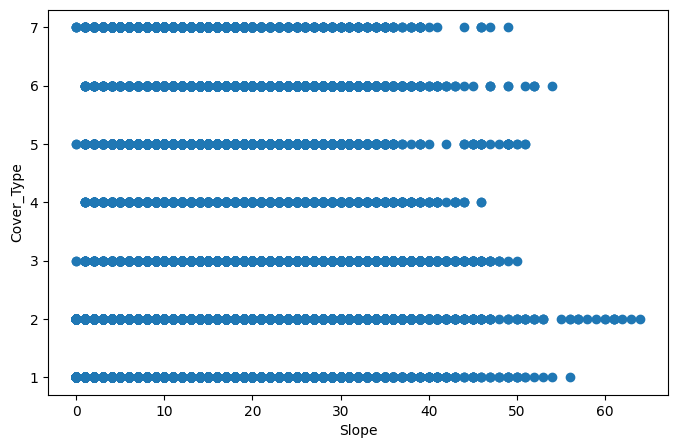

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(df["Slope"], df["Cover_Type"])
plt.xlabel("Slope")
plt.ylabel("Cover_Type")
plt.show()

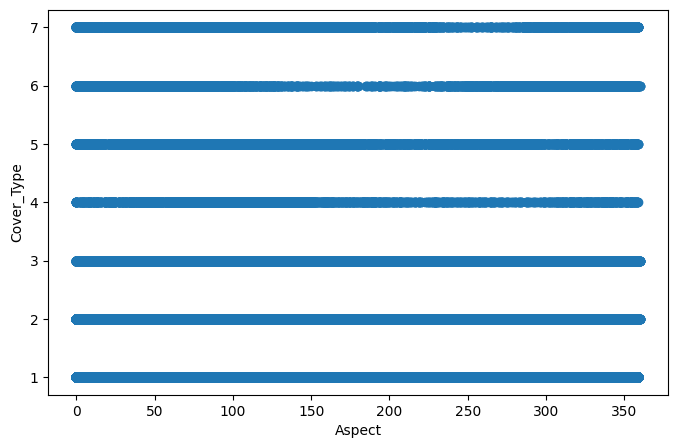

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(df["Aspect"], df["Cover_Type"])
plt.xlabel("Aspect")
plt.ylabel("Cover_Type")
plt.show()

In [8]:
X = df.drop("Cover_Type", axis=1)

y = df["Cover_Type"]

print(X.shape)
print(y.shape)

(267752, 54)
(267752,)


In [9]:
print("NaN values in y:", y.isna().sum())

print("Total NaN values in X:", X.isna().sum().sum())

print(y.head())

print(y.tail())

print(y.dtype)
df = df.dropna(subset=["Cover_Type"])

X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

NaN values in y: 1
Total NaN values in X: 19
0    5.0
1    5.0
2    2.0
3    2.0
4    5.0
Name: Cover_Type, dtype: float64
267747    3.0
267748    3.0
267749    3.0
267750    3.0
267751    NaN
Name: Cover_Type, dtype: float64
float64
(214200, 54)
(53551, 54)
(214200,)
(53551,)


In [10]:
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9483


In [11]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

         1.0       0.96      0.90      0.93     15109
         2.0       0.95      0.98      0.96     32602
         3.0       0.92      0.96      0.94      2277
         4.0       0.92      0.92      0.92       479
         5.0       0.94      0.81      0.87      1201
         6.0       0.92      0.83      0.87      1089
         7.0       0.95      0.90      0.93       794

    accuracy                           0.95     53551
   macro avg       0.93      0.90      0.92     53551
weighted avg       0.95      0.95      0.95     53551


Confusion Matrix:

[[13587  1482     0     0     6     3    31]
 [  514 31978    36     0    54    13     7]
 [    0    14  2182    31     3    47     0]
 [    0     0    31   439     0     9     0]
 [   12   202     5     0   974     8     0]
 [    2    39   129     9     3   907     0]
 [   71     7     0     0     0     0   716]]


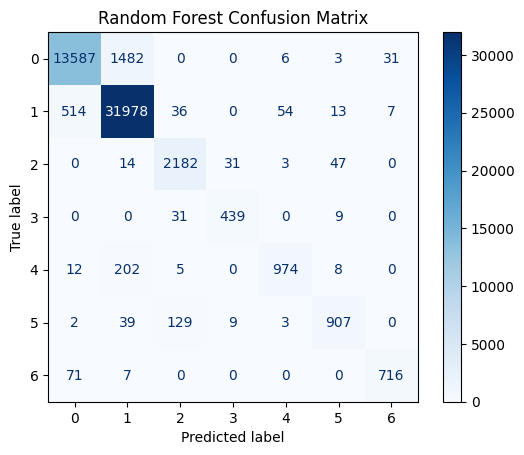

In [12]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [13]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_test)

In [14]:
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned Model Accuracy: 0.9304401411738343

Classification Report:

              precision    recall  f1-score   support

         1.0       0.96      0.85      0.90     15109
         2.0       0.92      0.98      0.95     32602
         3.0       0.90      0.96      0.93      2277
         4.0       0.91      0.90      0.90       479
         5.0       0.94      0.73      0.82      1201
         6.0       0.92      0.80      0.85      1089
         7.0       0.95      0.86      0.90       794

    accuracy                           0.93     53551
   macro avg       0.93      0.87      0.89     53551
weighted avg       0.93      0.93      0.93     53551


Confusion Matrix:

[[12772  2297     0     0     6     5    29]
 [  486 32011    43     1    42    13     6]
 [    0    20  2177    30     4    46     0]
 [    0     0    41   431     0     7     0]
 [   11   298     5     0   879     8     0]
 [    2    59   142    13     1   872     0]
 [  102     8     0     0     0     0   684]]


In [15]:
baseline_accuracy = accuracy_score(y_test, y_pred)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("Baseline Accuracy :", baseline_accuracy)
print("Tuned Accuracy    :", tuned_accuracy)

if tuned_accuracy > baseline_accuracy:
    print("\nThe tuned Random Forest model performed better.")
elif tuned_accuracy == baseline_accuracy:
    print("\nBoth models achieved the same accuracy.")
else:
    print("\nThe baseline Random Forest model performed better.")

Baseline Accuracy : 0.9483109559111874
Tuned Accuracy    : 0.9304401411738343

The baseline Random Forest model performed better.


In [16]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

In [17]:
print("Gradient Boosting Accuracy:")
print(accuracy_score(y_test, gb_pred))

print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

Gradient Boosting Accuracy:
0.8252880431737969

Classification Report:
              precision    recall  f1-score   support

         1.0       0.79      0.66      0.72     15109
         2.0       0.84      0.92      0.88     32602
         3.0       0.81      0.93      0.87      2277
         4.0       0.86      0.84      0.85       479
         5.0       0.79      0.48      0.60      1201
         6.0       0.80      0.50      0.62      1089
         7.0       0.87      0.60      0.71       794

    accuracy                           0.83     53551
   macro avg       0.82      0.71      0.75     53551
weighted avg       0.82      0.83      0.82     53551


Confusion Matrix:
[[10021  4985     0     0    35     3    65]
 [ 2254 30063   109     2   103    62     9]
 [    0    44  2107    55    12    59     0]
 [    0     0    71   404     0     4     0]
 [   20   589     9     0   578     5     0]
 [    2   231   297     9     6   544     0]
 [  315     1     0     0     0     0   478

In [18]:
rf_accuracy = accuracy_score(y_test, y_pred)
gb_accuracy = accuracy_score(y_test, gb_pred)

print("Random Forest Accuracy :", rf_accuracy)
print("Gradient Boosting Accuracy :", gb_accuracy)

if rf_accuracy > gb_accuracy:
    print("Random Forest performed better.")
else:
    print("Gradient Boosting performed better.")
best_model = rf_model if rf_accuracy >= gb_accuracy else gb_model

Random Forest Accuracy : 0.9483109559111874
Gradient Boosting Accuracy : 0.8252880431737969
Random Forest performed better.


In [19]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,Elevation,0.242030
5,Horizontal_Distance_To_Roadways,0.138772
9,Horizontal_Distance_To_Fire_Points,0.120521
3,Horizontal_Distance_To_Hydrology,0.057079
4,Vertical_Distance_To_Hydrology,0.057055
1,Aspect,0.047120
7,Hillshade_Noon,0.043748
8,Hillshade_3pm,0.042704
6,Hillshade_9am,0.040756
2,Slope,0.034315


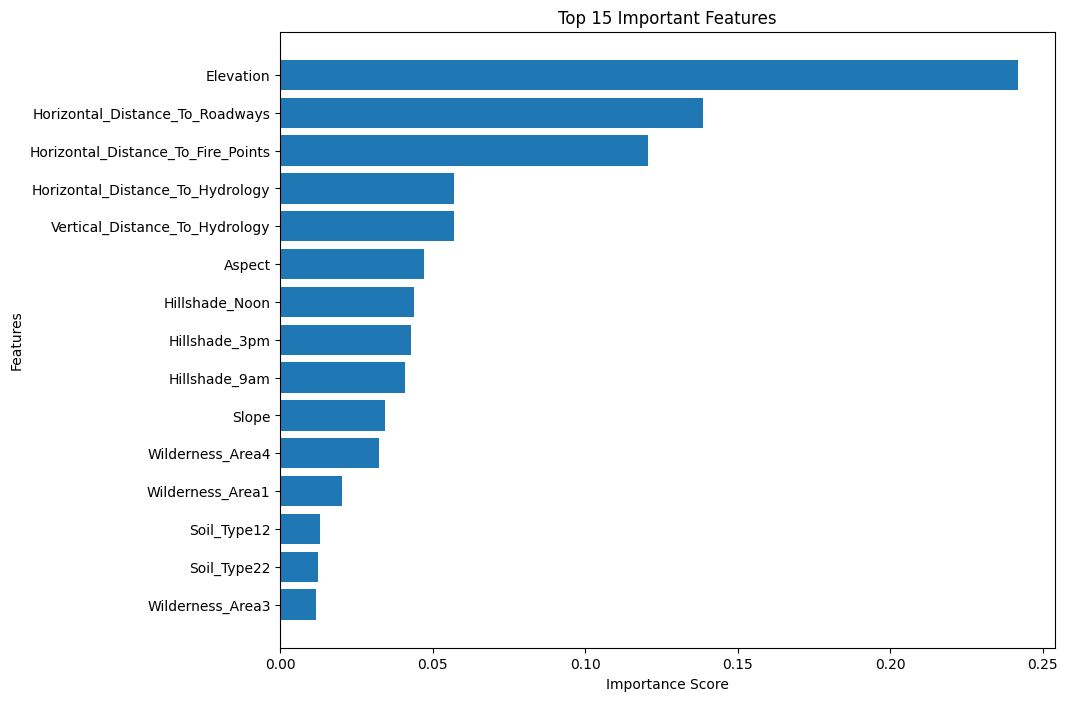

In [20]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [21]:
joblib.dump(best_model, "forest_cover_classifier.pkl")

print("Model saved successfully.")
loaded_model = joblib.load("forest_cover_classifier.pkl")

print("Model loaded successfully.")

Model saved successfully.
Model loaded successfully.


In [22]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Actual Class :", y_test.iloc[0])
print("Predicted Class :", prediction[0])

Actual Class : 1.0
Predicted Class : 1.0


In [23]:
sample_data = X_test.iloc[:5]

predictions = loaded_model.predict(sample_data)

results = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": predictions
})

results

,Actual,Predicted
0,1.0,1.0
1,2.0,2.0
2,1.0,1.0
3,4.0,4.0
4,2.0,2.0


In [24]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

In [25]:
print("Cross Validation Scores")

print(cv_scores)

print("\nAverage Accuracy:")

print(cv_scores.mean())

print("\nStandard Deviation:")

print(cv_scores.std())

Cross Validation Scores
[0.70743777 0.74485528 0.69979458 0.64539683 0.61652661]

Average Accuracy:
0.6828022131175738

Standard Deviation:
0.04590828331863107


In [ ]:
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[20,30,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
print("Best Parameters")

print(grid_search.best_params_)

print("\nBest Accuracy")

print(grid_search.best_score_)

In [ ]:
best_rf = grid_search.best_estimator_
best_prediction = best_rf.predict(X_test)
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,best_prediction))

In [ ]:
print(classification_report(
    y_test,
    best_prediction
))
cm = confusion_matrix(
    y_test,
    best_prediction
)

print(cm)

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Blues")

In [ ]:
joblib.dump(best_rf, "forest_cover_classifier.pkl")
print("Model saved successfully.")
loaded_model = joblib.load("forest_cover_classifier.pkl")
print("Model loaded successfully.")
sample = X_test.iloc[[0]]
prediction = loaded_model.predict(sample)
print("Predicted Forest Cover Type:", prediction[0])

In [ ]:
print("Actual Class:", y_test.iloc[0])
print("Predicted Class:", prediction[0])
predictions = loaded_model.predict(X_test.iloc[:10])
comparison = X_test.iloc[:10].copy()
comparison["Actual"] = y_test.iloc[:10].values
comparison["Predicted"] = predictions
comparison[["Actual", "Predicted"]]